In [64]:
import numpy as np
import pandas as pd
from conda.core.initialize import initialize
from  sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,log_loss
import matplotlib.pyplot as plt
import seaborn as sns



In [65]:
df=pd.read_csv("../Datasets/Kyphosis.csv")
df.columns

Index(['Kyphosis', 'Age', 'Number', 'Start'], dtype='str')

In [66]:
print(df.shape)
print(df.head(2))

(81, 4)
  Kyphosis  Age  Number  Start
0   absent   71       3      5
1   absent  158       3     14


In [67]:
encoder = LabelEncoder()
y = encoder.fit_transform(df["Kyphosis"])
x=df.drop(columns=["Kyphosis"])


In [68]:
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.3,random_state=25)

In [69]:
min_max=MinMaxScaler().set_output(transform="pandas")
x_train_scaler=min_max.fit_transform(X_train)
x_test_scaler=min_max.transform(X_test)
print(x_train_scaler.shape)
print(x_test_scaler.shape)

(56, 3)
(25, 3)


In [70]:
x1,x2,x3=x_train_scaler["Age"],x_train_scaler["Number"],x_train_scaler["Start"]
print(x1)

17    0.896907
46    0.695876
19    0.134021
63    0.603093
26    0.036082
56    0.005155
67    0.814433
11    0.757732
43    0.309278
57    0.613402
5     0.000000
2     0.654639
30    0.154639
34    0.716495
49    0.907216
72    0.443299
18    0.407216
27    0.510309
59    0.520619
60    0.664948
42    0.731959
10    0.417526
32    0.664948
65    0.082474
36    0.000000
21    0.536082
74    0.051546
79    0.211340
75    0.912371
16    0.396907
9     0.298969
47    0.670103
48    0.618557
70    0.809278
22    0.489691
68    0.087629
64    0.603093
45    0.711340
20    0.108247
66    1.000000
55    0.365979
3     0.005155
39    0.463918
1     0.809278
69    0.072165
31    0.639175
80    0.180412
28    0.015464
8     0.577320
50    0.345361
44    0.494845
23    0.670103
61    0.582474
15    0.000000
62    0.412371
4     0.000000
Name: Age, dtype: float64


In [71]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

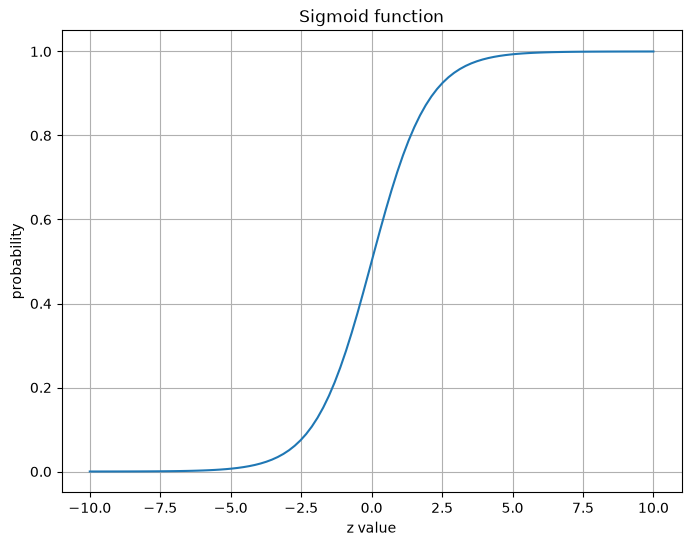

In [72]:
z=np.linspace(-10,10,100)
plt.figure(figsize=(8,6))
plt.plot(z,sigmoid(z),label="sigmoid")
plt.title("Sigmoid function")
plt.xlabel("z value")
plt.ylabel("probability")
plt.grid(True)
plt.show()

In [73]:
eta=0.1
epoch=10000
w1,w2,w3=0.1,0.1,0.1
b=0.1

In [74]:
batch_loss=list()

for i in range(1000):

    # 1. Forward propagation
    y_curve = sigmoid(w1*x1 + w2*x2 + w3*x3 + b)

    # 2. Calculate loss
    l1 = log_loss(Y_train, y_curve)

    # 3. Store loss
    batch_loss.append(l1)

    if i % 100 == 0:
        print(f"{i}, loss: {l1}")

        # 4. Calculate gradients
        dw1 = np.mean((y_curve-Y_train)*x1)
        dw2 = np.mean((y_curve-Y_train)*x2)
        dw3 = np.mean((y_curve-Y_train)*x3)
        dv  = np.mean((y_curve-Y_train))

        # 5. Update parameters
        w1 = w1 - eta*dw1
        w2 = w2 - eta*dw2
        w3 = w3 - eta*dw3
        b  = b - eta*dv

0, loss: 0.769128676751426
100, loss: 0.7476508330481195
200, loss: 0.7279630656851906
300, loss: 0.709923175294344
400, loss: 0.6933965737891408
500, loss: 0.6782568465923772
600, loss: 0.6643860256596803
700, loss: 0.6516746301564341
800, loss: 0.640021527199122
900, loss: 0.6293336588954178


In [75]:
print("Final batch is",batch_loss[-1])

Final batch is 0.6195256750179418


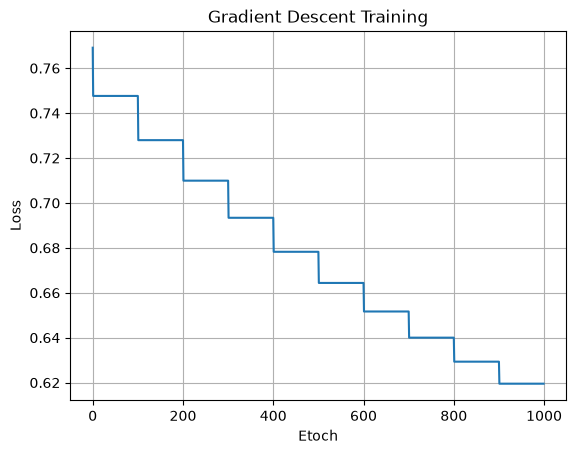

In [76]:
plt.Figure(figsize=(8,6))
plt.plot(batch_loss,label="Training Loss")
plt.title("Gradient Descent Training")
plt.xlabel("Etoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [77]:
y_preb_prop = sigmoid(
    w1*x_test_scaler["Age"] +
    w2*x_test_scaler["Number"] +
    w3*x_test_scaler["Start"] +
    b
)

print("Log Plot on test case \n", log_loss(Y_test, y_preb_prop))

Log Plot on test case 
 0.6115110626877474


In [78]:
y_pred=np.where(y_preb_prop>0.5,1,0)
print(y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [79]:
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89        20
           1       0.00      0.00      0.00         5

    accuracy                           0.80        25
   macro avg       0.40      0.50      0.44        25
weighted avg       0.64      0.80      0.71        25



c:\Users\UserE\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\UserE\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\UserE\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
